In [14]:
# =========================================================
# HW08-09
# Готовый каркас: MLP, Dropout, BatchNorm, EarlyStopping,
# Adam vs SGD+momentum, weight decay, графики, runs.csv
# =========================================================

import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [15]:
# =========================================================
# HW08-09
# Готовый каркас: MLP, Dropout, BatchNorm, EarlyStopping,
# Adam vs SGD+momentum, weight decay, графики, runs.csv
# =========================================================

import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [16]:
# ---------------------------------------------------------
# Фиксируем seed
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [17]:
# ---------------------------------------------------------
# Папки под домашку и артефакты
# ---------------------------------------------------------
BASE_DIR = Path(".")
ART_DIR = BASE_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"

ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts:", ART_DIR.resolve())
print("Figures:", FIG_DIR.resolve())

Artifacts: C:\Users\Elek1\github\Digital-competencies_Seminar_engineering-\homeworks\HW08-09\artifacts
Figures: C:\Users\Elek1\github\Digital-competencies_Seminar_engineering-\homeworks\HW08-09\artifacts\figures


In [18]:
# ---------------------------------------------------------
# Временный synthetic dataset без скачивания
# Формат специально сделан как у MNIST/KMNIST: [N, 1, 28, 28]
# ---------------------------------------------------------
N = 3000
NUM_CLASSES = 10

X_data = torch.rand(N, 1, 28, 28)
y_data = torch.randint(0, NUM_CLASSES, (N,))

full_dataset = TensorDataset(X_data, y_data)

print("Dataset size:", len(full_dataset))
print("X shape:", X_data.shape)
print("y shape:", y_data.shape)

Dataset size: 3000
X shape: torch.Size([3000, 1, 28, 28])
y shape: torch.Size([3000])


In [19]:
# ---------------------------------------------------------
# Train / Val / Test split
# ---------------------------------------------------------
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 2100
Val size: 450
Test size: 450


In [20]:
# ---------------------------------------------------------
# Sanity-check
# ---------------------------------------------------------
xb, yb = next(iter(train_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb min/max:", xb.min().item(), xb.max().item())
print("yb[:10]:", yb[:10])

xb.shape: torch.Size([64, 1, 28, 28])
yb.shape: torch.Size([64])
xb min/max: 2.4974346160888672e-05 0.999965488910675
yb[:10]: tensor([6, 3, 0, 5, 4, 7, 3, 9, 5, 5])


In [21]:
# ---------------------------------------------------------
# Гибкая MLP-модель
# ---------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim=28*28, num_classes=10,
                 hidden_sizes=(256, 128),
                 dropout=0.0,
                 use_batchnorm=False):
        super().__init__()

        layers = [nn.Flatten()]
        in_features = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = h

        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [22]:
# ---------------------------------------------------------
# Проверка forward pass
# ---------------------------------------------------------
model = MLP().to(device)
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

logits = model(xb)
print("logits.shape:", logits.shape)

logits.shape: torch.Size([64, 10])


In [23]:
# ---------------------------------------------------------
# Одна эпоха обучения
# ---------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [24]:
# ---------------------------------------------------------
# Оценка модели
# ---------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [25]:
# ---------------------------------------------------------
# График истории обучения
# ---------------------------------------------------------
def plot_history(history, title, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title}: Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title}: Accuracy")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [26]:
# ---------------------------------------------------------
# Универсальный запуск эксперимента
# ---------------------------------------------------------
def run_experiment(
    experiment_id,
    dataset_name,
    model_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False,
    patience=4,
):
    model = MLP(**model_kwargs).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        raise ValueError("Unsupported optimizer")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0

    wait = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        print(
            f"{experiment_id} | epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if early_stopping and wait >= patience:
            print(f"{experiment_id}: early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": SEED,
        "model_summary": json.dumps(model_kwargs, ensure_ascii=False),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }

    return model, history, result

In [27]:
# ---------------------------------------------------------
# Список результатов
# ---------------------------------------------------------
all_results = []
all_histories = {}
all_models = {}

In [28]:
# ---------------------------------------------------------
# E1: базовая модель
# ---------------------------------------------------------
E1_kwargs = {
    "hidden_sizes": (256, 128),
    "dropout": 0.0,
    "use_batchnorm": False
}

model_E1, history_E1, result_E1 = run_experiment(
    experiment_id="E1",
    dataset_name="synthetic",
    model_kwargs=E1_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=10
)

all_results.append(result_E1)
all_histories["E1"] = history_E1
all_models["E1"] = model_E1

E1 | epoch 1/10 | train_loss=2.3124 train_acc=0.1043 | val_loss=2.3175 val_acc=0.0733
E1 | epoch 2/10 | train_loss=2.3034 train_acc=0.1100 | val_loss=2.3126 val_acc=0.0978
E1 | epoch 3/10 | train_loss=2.3001 train_acc=0.1124 | val_loss=2.3082 val_acc=0.0844
E1 | epoch 4/10 | train_loss=2.2974 train_acc=0.1114 | val_loss=2.3077 val_acc=0.0800
E1 | epoch 5/10 | train_loss=2.2970 train_acc=0.1190 | val_loss=2.3125 val_acc=0.0733
E1 | epoch 6/10 | train_loss=2.2894 train_acc=0.1510 | val_loss=2.3157 val_acc=0.0956
E1 | epoch 7/10 | train_loss=2.2807 train_acc=0.1338 | val_loss=2.3115 val_acc=0.0600
E1 | epoch 8/10 | train_loss=2.2645 train_acc=0.1586 | val_loss=2.3345 val_acc=0.0978
E1 | epoch 9/10 | train_loss=2.2489 train_acc=0.1567 | val_loss=2.3125 val_acc=0.1089
E1 | epoch 10/10 | train_loss=2.2065 train_acc=0.2105 | val_loss=2.3508 val_acc=0.0778


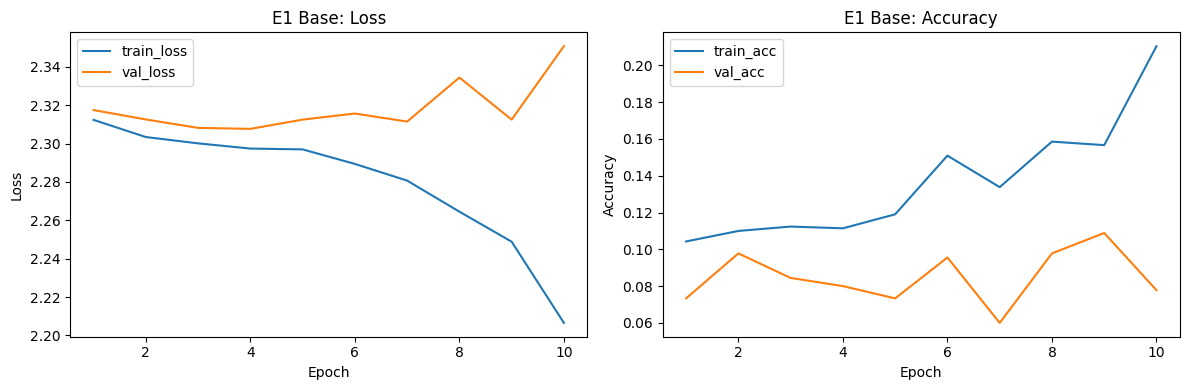

In [29]:
plot_history(history_E1, "E1 Base")

In [30]:
# ---------------------------------------------------------
# E2: Dropout
# ---------------------------------------------------------
E2_kwargs = {
    "hidden_sizes": (256, 128),
    "dropout": 0.3,
    "use_batchnorm": False
}

model_E2, history_E2, result_E2 = run_experiment(
    experiment_id="E2",
    dataset_name="synthetic",
    model_kwargs=E2_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=10
)

all_results.append(result_E2)
all_histories["E2"] = history_E2
all_models["E2"] = model_E2

E2 | epoch 1/10 | train_loss=2.3184 train_acc=0.1110 | val_loss=2.3087 val_acc=0.0933
E2 | epoch 2/10 | train_loss=2.3081 train_acc=0.1076 | val_loss=2.3064 val_acc=0.0978
E2 | epoch 3/10 | train_loss=2.3033 train_acc=0.1076 | val_loss=2.3074 val_acc=0.1067
E2 | epoch 4/10 | train_loss=2.3040 train_acc=0.1081 | val_loss=2.3083 val_acc=0.0978
E2 | epoch 5/10 | train_loss=2.3009 train_acc=0.1186 | val_loss=2.3076 val_acc=0.0733
E2 | epoch 6/10 | train_loss=2.2982 train_acc=0.1238 | val_loss=2.3100 val_acc=0.0733
E2 | epoch 7/10 | train_loss=2.2976 train_acc=0.1176 | val_loss=2.3084 val_acc=0.0733
E2 | epoch 8/10 | train_loss=2.2968 train_acc=0.1171 | val_loss=2.3092 val_acc=0.0733
E2 | epoch 9/10 | train_loss=2.2954 train_acc=0.1162 | val_loss=2.3085 val_acc=0.1067
E2 | epoch 10/10 | train_loss=2.2932 train_acc=0.1329 | val_loss=2.3071 val_acc=0.0733


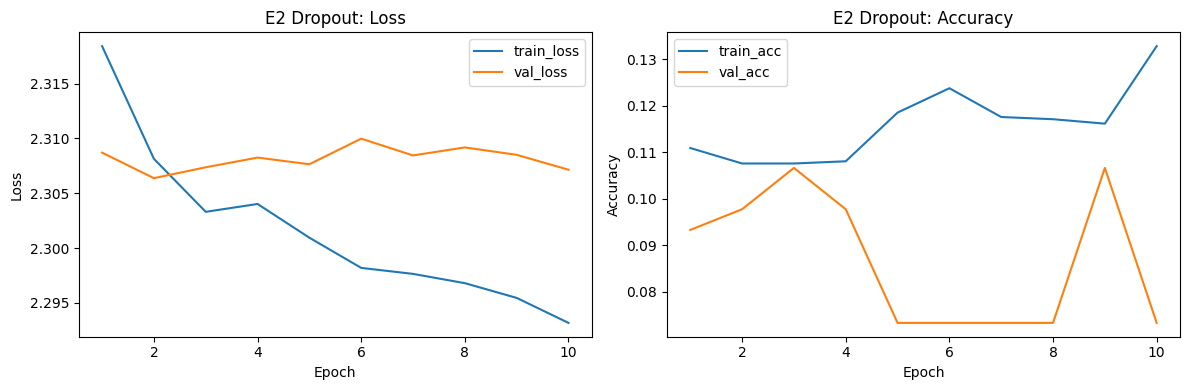

In [31]:
plot_history(history_E2, "E2 Dropout")

In [32]:
# ---------------------------------------------------------
# E3: BatchNorm
# ---------------------------------------------------------
E3_kwargs = {
    "hidden_sizes": (256, 128),
    "dropout": 0.0,
    "use_batchnorm": True
}

model_E3, history_E3, result_E3 = run_experiment(
    experiment_id="E3",
    dataset_name="synthetic",
    model_kwargs=E3_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=10
)

all_results.append(result_E3)
all_histories["E3"] = history_E3
all_models["E3"] = model_E3

E3 | epoch 1/10 | train_loss=2.3757 train_acc=0.1019 | val_loss=2.3121 val_acc=0.0911
E3 | epoch 2/10 | train_loss=1.5053 train_acc=0.7914 | val_loss=2.3977 val_acc=0.0978
E3 | epoch 3/10 | train_loss=0.8443 train_acc=0.9490 | val_loss=2.6218 val_acc=0.1200
E3 | epoch 4/10 | train_loss=0.3231 train_acc=0.9952 | val_loss=2.8974 val_acc=0.1200
E3 | epoch 5/10 | train_loss=0.1150 train_acc=1.0000 | val_loss=3.0843 val_acc=0.1133
E3 | epoch 6/10 | train_loss=0.0533 train_acc=1.0000 | val_loss=3.2145 val_acc=0.1156
E3 | epoch 7/10 | train_loss=0.0311 train_acc=1.0000 | val_loss=3.2991 val_acc=0.1156
E3 | epoch 8/10 | train_loss=0.0216 train_acc=1.0000 | val_loss=3.3786 val_acc=0.1178
E3 | epoch 9/10 | train_loss=0.0155 train_acc=1.0000 | val_loss=3.4561 val_acc=0.1200
E3 | epoch 10/10 | train_loss=0.0127 train_acc=1.0000 | val_loss=3.4990 val_acc=0.1089


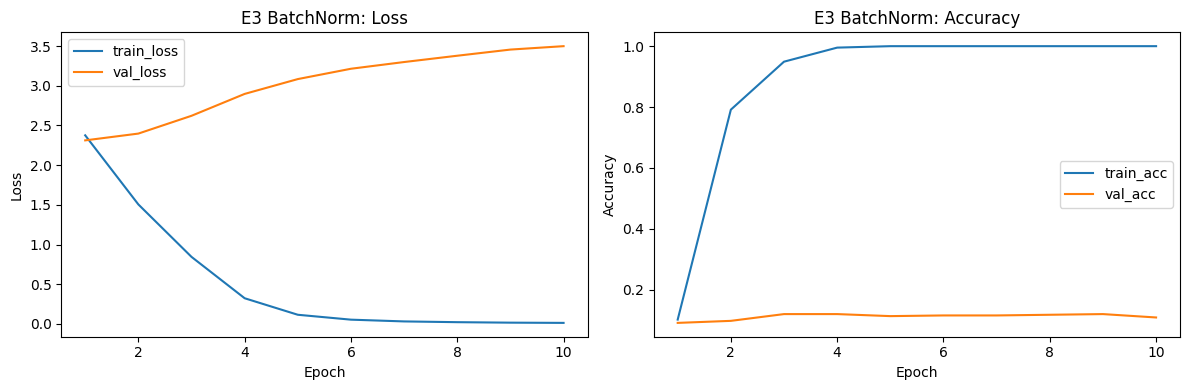

In [33]:
plot_history(history_E3, "E3 BatchNorm")

In [34]:
# ---------------------------------------------------------
# Выбираем лучший из E2/E3 по val_accuracy
# ---------------------------------------------------------
candidates = [result_E2, result_E3]
best_pre_es = max(candidates, key=lambda x: x["best_val_accuracy"])

print("Best between E2/E3:", best_pre_es["experiment_id"])
best_pre_es

Best between E2/E3: E3


{'experiment_id': 'E3',
 'dataset': 'synthetic',
 'seed': 42,
 'model_summary': '{"hidden_sizes": [256, 128], "dropout": 0.0, "use_batchnorm": true}',
 'optimizer': 'Adam',
 'lr': 0.001,
 'momentum': 0.0,
 'weight_decay': 0.0,
 'epochs_trained': 10,
 'best_val_accuracy': 0.12,
 'best_val_loss': 2.621772043440077,
 'best_epoch': 3}

In [35]:
# ---------------------------------------------------------
# E4: EarlyStopping на лучшей модели из E2/E3
# ---------------------------------------------------------
if best_pre_es["experiment_id"] == "E2":
    E4_kwargs = E2_kwargs
else:
    E4_kwargs = E3_kwargs

model_E4, history_E4, result_E4 = run_experiment(
    experiment_id="E4",
    dataset_name="synthetic",
    model_kwargs=E4_kwargs,
    optimizer_name="Adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=20,
    early_stopping=True,
    patience=4
)

all_results.append(result_E4)
all_histories["E4"] = history_E4
all_models["E4"] = model_E4

E4 | epoch 1/20 | train_loss=2.3631 train_acc=0.0981 | val_loss=2.3241 val_acc=0.1222
E4 | epoch 2/20 | train_loss=1.5187 train_acc=0.7790 | val_loss=2.4539 val_acc=0.1044
E4 | epoch 3/20 | train_loss=0.8573 train_acc=0.9424 | val_loss=2.7108 val_acc=0.0889
E4 | epoch 4/20 | train_loss=0.3356 train_acc=0.9952 | val_loss=2.9354 val_acc=0.0978
E4 | epoch 5/20 | train_loss=0.1150 train_acc=1.0000 | val_loss=3.1540 val_acc=0.0933
E4: early stopping at epoch 5


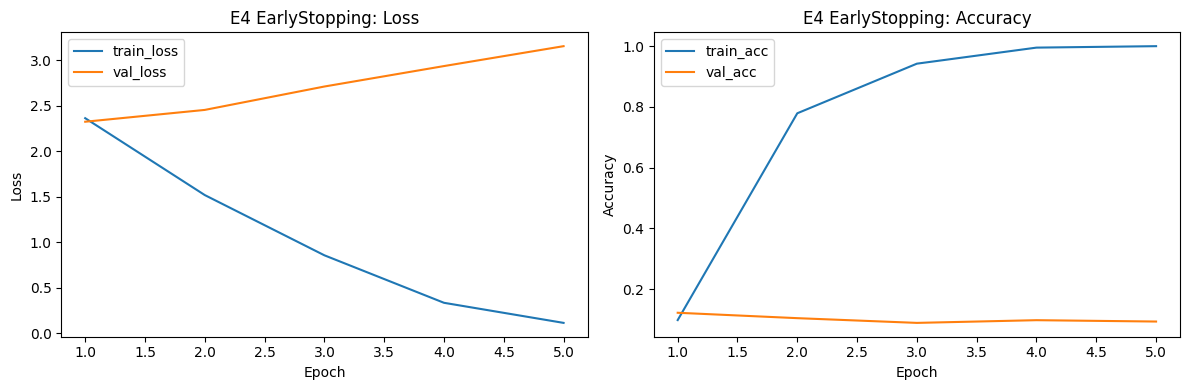

In [36]:
plot_history(history_E4, "E4 EarlyStopping", FIG_DIR / "curves_best.png")

In [37]:
# ---------------------------------------------------------
# Сохраняем лучшую модель домашки (E4)
# ---------------------------------------------------------
best_model = model_E4
best_config = {
    "dataset": "synthetic",
    "seed": SEED,
    "model_kwargs": E4_kwargs,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "early_stopping": True,
    "patience": 4
}

torch.save(best_model.state_dict(), ART_DIR / "best_model.pt")

with open(ART_DIR / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print("Saved best_model.pt and best_config.json")

Saved best_model.pt and best_config.json


In [38]:
# ---------------------------------------------------------
# O1: слишком большой LR
# ---------------------------------------------------------
model_O1, history_O1, result_O1 = run_experiment(
    experiment_id="O1",
    dataset_name="synthetic",
    model_kwargs=E4_kwargs,
    optimizer_name="Adam",
    lr=1e-1,
    weight_decay=0.0,
    epochs=6
)

all_results.append(result_O1)
all_histories["O1"] = history_O1
all_models["O1"] = model_O1

O1 | epoch 1/6 | train_loss=2.6200 train_acc=0.0948 | val_loss=2.3249 val_acc=0.0889
O1 | epoch 2/6 | train_loss=2.3036 train_acc=0.1081 | val_loss=2.3164 val_acc=0.1067
O1 | epoch 3/6 | train_loss=2.2770 train_acc=0.1314 | val_loss=2.3646 val_acc=0.0889
O1 | epoch 4/6 | train_loss=2.1975 train_acc=0.1695 | val_loss=2.4428 val_acc=0.0911
O1 | epoch 5/6 | train_loss=2.0930 train_acc=0.2129 | val_loss=2.5993 val_acc=0.0867
O1 | epoch 6/6 | train_loss=1.9797 train_acc=0.2605 | val_loss=2.7282 val_acc=0.0822


In [39]:
# ---------------------------------------------------------
# O2: слишком маленький LR
# ---------------------------------------------------------
model_O2, history_O2, result_O2 = run_experiment(
    experiment_id="O2",
    dataset_name="synthetic",
    model_kwargs=E4_kwargs,
    optimizer_name="Adam",
    lr=1e-5,
    weight_decay=0.0,
    epochs=6
)

all_results.append(result_O2)
all_histories["O2"] = history_O2
all_models["O2"] = model_O2

O2 | epoch 1/6 | train_loss=2.3771 train_acc=0.1019 | val_loss=2.3360 val_acc=0.0956
O2 | epoch 2/6 | train_loss=2.3613 train_acc=0.1090 | val_loss=2.3732 val_acc=0.0889
O2 | epoch 3/6 | train_loss=2.3480 train_acc=0.1138 | val_loss=2.3756 val_acc=0.0933
O2 | epoch 4/6 | train_loss=2.3346 train_acc=0.1300 | val_loss=2.3751 val_acc=0.0911
O2 | epoch 5/6 | train_loss=2.3176 train_acc=0.1262 | val_loss=2.3731 val_acc=0.0933
O2 | epoch 6/6 | train_loss=2.3050 train_acc=0.1314 | val_loss=2.3714 val_acc=0.0933


In [40]:
# ---------------------------------------------------------
# O3: SGD + momentum + weight decay
# ---------------------------------------------------------
model_O3, history_O3, result_O3 = run_experiment(
    experiment_id="O3",
    dataset_name="synthetic",
    model_kwargs=E4_kwargs,
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=12
)

all_results.append(result_O3)
all_histories["O3"] = history_O3
all_models["O3"] = model_O3

O3 | epoch 1/12 | train_loss=2.3635 train_acc=0.0919 | val_loss=2.3207 val_acc=0.1111
O3 | epoch 2/12 | train_loss=1.7109 train_acc=0.6329 | val_loss=2.4448 val_acc=0.0889
O3 | epoch 3/12 | train_loss=0.9310 train_acc=0.8848 | val_loss=2.7467 val_acc=0.0956
O3 | epoch 4/12 | train_loss=0.3014 train_acc=0.9890 | val_loss=3.0885 val_acc=0.0911
O3 | epoch 5/12 | train_loss=0.0922 train_acc=1.0000 | val_loss=3.2682 val_acc=0.0956
O3 | epoch 6/12 | train_loss=0.0436 train_acc=1.0000 | val_loss=3.3990 val_acc=0.0956
O3 | epoch 7/12 | train_loss=0.0286 train_acc=1.0000 | val_loss=3.4875 val_acc=0.0911
O3 | epoch 8/12 | train_loss=0.0212 train_acc=1.0000 | val_loss=3.5511 val_acc=0.0956
O3 | epoch 9/12 | train_loss=0.0169 train_acc=1.0000 | val_loss=3.6218 val_acc=0.0911
O3 | epoch 10/12 | train_loss=0.0141 train_acc=1.0000 | val_loss=3.6836 val_acc=0.0911
O3 | epoch 11/12 | train_loss=0.0114 train_acc=1.0000 | val_loss=3.7064 val_acc=0.0911
O3 | epoch 12/12 | train_loss=0.0102 train_acc=1.000

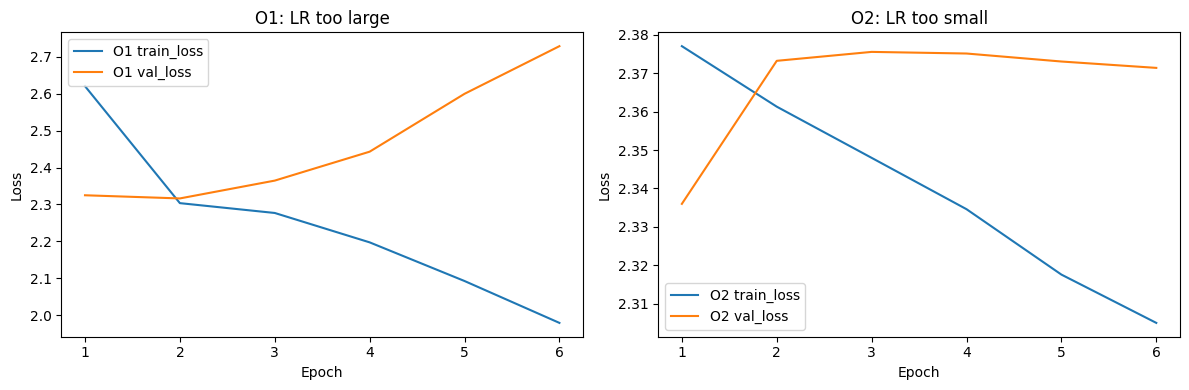

In [41]:
# ---------------------------------------------------------
# График O1 и O2
# ---------------------------------------------------------
epochs_o1 = range(1, len(history_O1["train_loss"]) + 1)
epochs_o2 = range(1, len(history_O2["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_o1, history_O1["train_loss"], label="O1 train_loss")
plt.plot(epochs_o1, history_O1["val_loss"], label="O1 val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("O1: LR too large")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_o2, history_O2["train_loss"], label="O2 train_loss")
plt.plot(epochs_o2, history_O2["val_loss"], label="O2 val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("O2: LR too small")
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "curves_lr_extremes.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
# ---------------------------------------------------------
# Финальная оценка лучшей модели на test
# ---------------------------------------------------------
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 2.3301
Test accuracy: 0.0956


In [43]:
# ---------------------------------------------------------
# Таблица всех экспериментов
# ---------------------------------------------------------
runs_df = pd.DataFrame(all_results)
runs_df.to_csv(ART_DIR / "runs.csv", index=False)

runs_df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch
0,E1,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00100,0.0,0.0000,10,0.108889,2.312527,9
1,E2,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.3, ""...",Adam,0.00100,0.0,0.0000,10,0.106667,2.307367,3
2,E3,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00100,0.0,0.0000,10,0.120000,2.621772,3
3,E4,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00100,0.0,0.0000,5,0.122222,2.324137,1
4,O1,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.10000,0.0,0.0000,6,0.106667,2.316361,2
5,O2,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",Adam,0.00001,0.0,0.0000,6,0.095556,2.335988,1
6,O3,synthetic,42,"{""hidden_sizes"": [256, 128], ""dropout"": 0.0, ""...",SGD,0.01000,0.9,0.0001,12,0.111111,2.320668,1


In [44]:
# ---------------------------------------------------------
# Проверяем, что всё сохранилось
# ---------------------------------------------------------
for p in sorted(ART_DIR.rglob("*")):
    print(p)

artifacts\best_config.json
artifacts\best_model.pt
artifacts\figures
artifacts\figures\curves_best.png
artifacts\figures\curves_lr_extremes.png
artifacts\runs.csv
